(421570, 16)
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106  

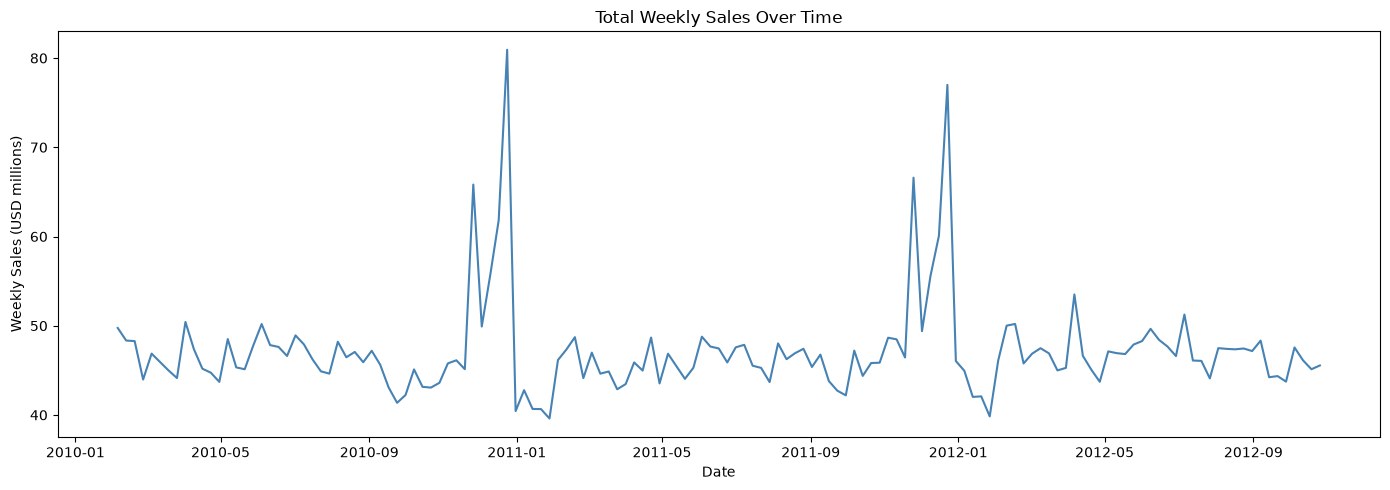

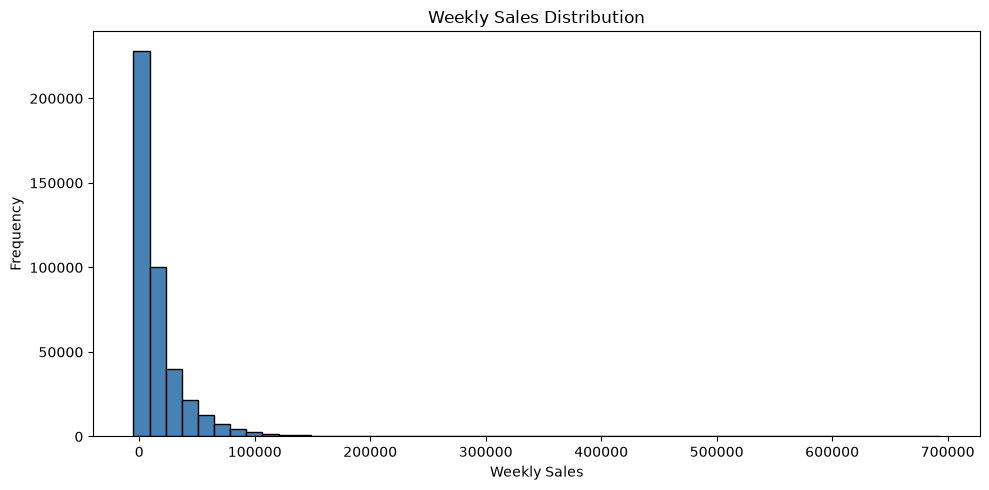

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

train = pd.read_csv('../data/train.csv')
features = pd.read_csv('../data/features.csv')
stores = pd.read_csv('../data/stores.csv')

df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.describe())

os.makedirs('../outputs', exist_ok=True)

weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_total['Weekly_Sales_M'] = weekly_total['Weekly_Sales'] / 1e6

plt.figure(figsize=(14, 5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales_M'], color='steelblue', linewidth=1.5)
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales (USD millions)')
plt.tight_layout()
plt.savefig('../outputs/sales_over_time.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df['Weekly_Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Weekly Sales Distribution')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/sales_distribution.png')
plt.show()